In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "student-mat.csv").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "student-mat.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "student_risk_pipeline.joblib"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Matplotlib is building the font cache; this may take a moment.


Project root: f:\AI_DS_ML\ML01-intern
Dataset path: f:\AI_DS_ML\ML01-intern\data\student-mat.csv


In [2]:
df = pd.read_csv(DATA_PATH, sep=";")

print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {int(df.isna().sum().sum())}")

display(df.head())
display(df.dtypes.rename("dtype").to_frame())
display(df.describe(include="all").T)

assert df.shape == (395, 33)
assert df.isna().sum().sum() == 0
assert {"G1", "G2", "G3"}.issubset(df.columns)


Shape: (395, 33)
Duplicate rows: 0
Missing values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


,dtype
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Risk class counts:


,count
at_risk,
not at risk,265
at risk,130


Risk class proportions:


,proportion
at_risk,
not at risk,0.670886
at risk,0.329114


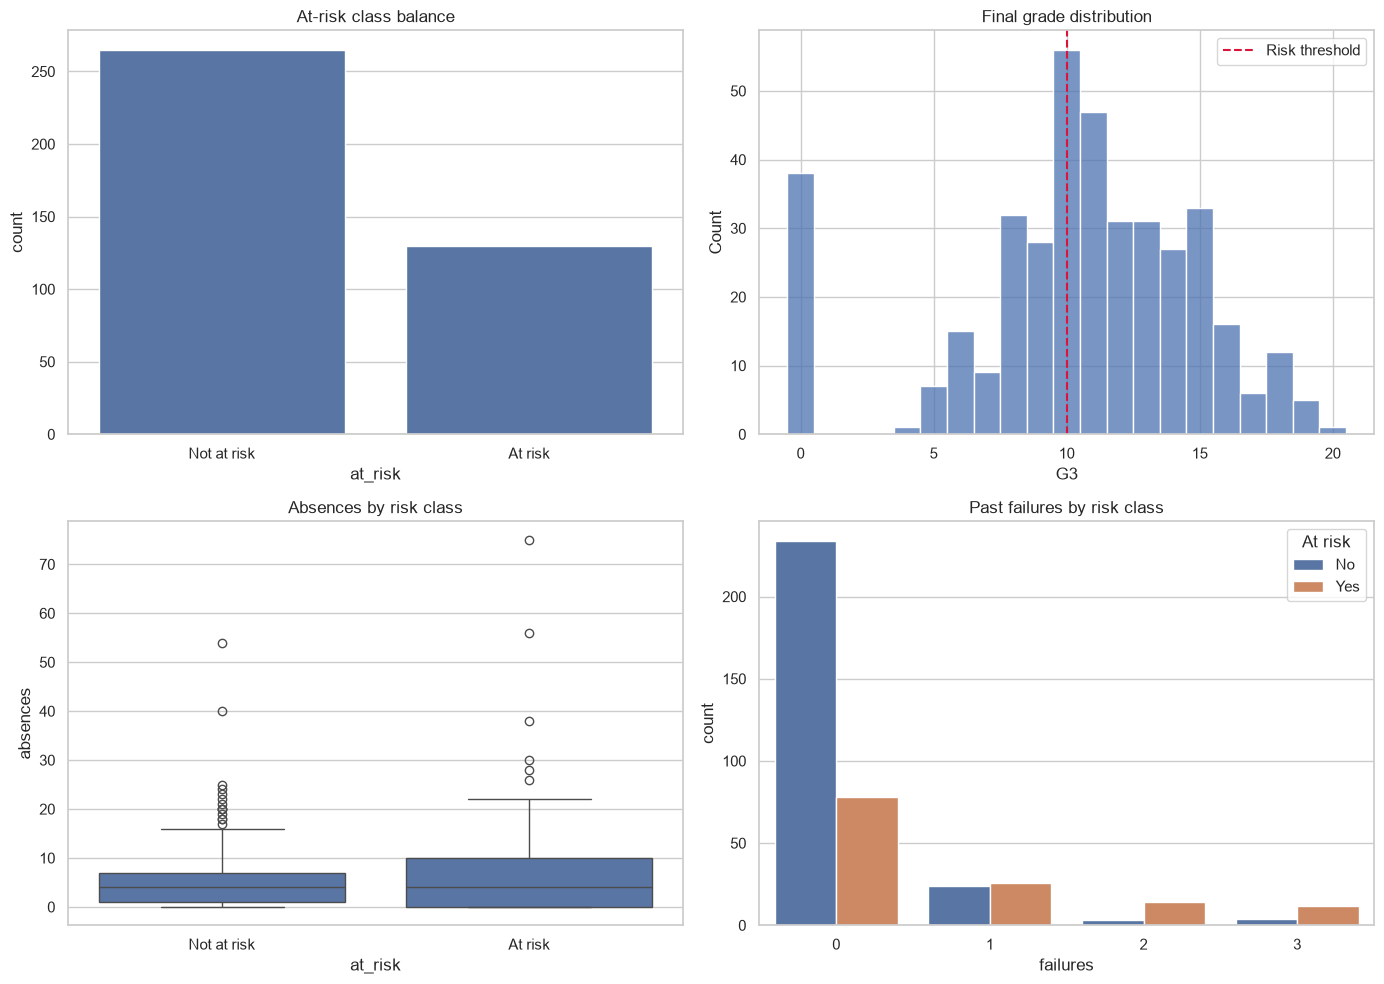

Model features: 30


In [3]:
TARGET_COLUMN = "at_risk"
LEAKAGE_COLUMNS = ["G1", "G2", "G3"]

model_df = df.copy()
model_df[TARGET_COLUMN] = (model_df["G3"] < 10).astype(int)

print("Risk class counts:")
display(model_df[TARGET_COLUMN].value_counts().rename(index={0: "not at risk", 1: "at risk"}).to_frame("count"))
print("Risk class proportions:")
display(model_df[TARGET_COLUMN].value_counts(normalize=True).rename(index={0: "not at risk", 1: "at risk"}).to_frame("proportion"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=model_df, x=TARGET_COLUMN, ax=axes[0, 0])
axes[0, 0].set_title("At-risk class balance")
axes[0, 0].set_xticks([0, 1], ["Not at risk", "At risk"])

sns.histplot(data=model_df, x="G3", discrete=True, ax=axes[0, 1])
axes[0, 1].axvline(10, color="crimson", linestyle="--", label="Risk threshold")
axes[0, 1].set_title("Final grade distribution")
axes[0, 1].legend()

sns.boxplot(data=model_df, x=TARGET_COLUMN, y="absences", ax=axes[1, 0])
axes[1, 0].set_title("Absences by risk class")
axes[1, 0].set_xticks([0, 1], ["Not at risk", "At risk"])

sns.countplot(data=model_df, x="failures", hue=TARGET_COLUMN, ax=axes[1, 1])
axes[1, 1].set_title("Past failures by risk class")
axes[1, 1].legend(title="At risk", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

feature_columns = [column for column in model_df.columns if column not in LEAKAGE_COLUMNS + [TARGET_COLUMN]]
X = model_df[feature_columns].copy()
y = model_df[TARGET_COLUMN].copy()

assert not set(LEAKAGE_COLUMNS).intersection(X.columns)
assert len(X) == len(y) == 395
print(f"Model features: {X.shape[1]}")


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} fitted")

assert set(X_train.index).isdisjoint(set(X_test.index))
assert set(LEAKAGE_COLUMNS).isdisjoint(X_train.columns)


Logistic Regression fitted
Random Forest fitted



Logistic Regression classification report
              precision    recall  f1-score   support

 Not at risk       0.72      0.89      0.80        53
     At risk       0.57      0.31      0.40        26

    accuracy                           0.70        79
   macro avg       0.65      0.60      0.60        79
weighted avg       0.67      0.70      0.67        79


Random Forest classification report
              precision    recall  f1-score   support

 Not at risk       0.76      0.83      0.79        53
     At risk       0.57      0.46      0.51        26

    accuracy                           0.71        79
   macro avg       0.67      0.65      0.65        79
weighted avg       0.70      0.71      0.70        79



,model,accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,Random Forest,0.708861,0.571429,0.461538,0.510638,0.692308
1,Logistic Regression,0.696203,0.571429,0.307692,0.400000,0.714804


,cv_f1,cv_recall,cv_roc_auc
Logistic Regression,0.401102,0.337619,0.632554
Random Forest,0.459465,0.424762,0.656768


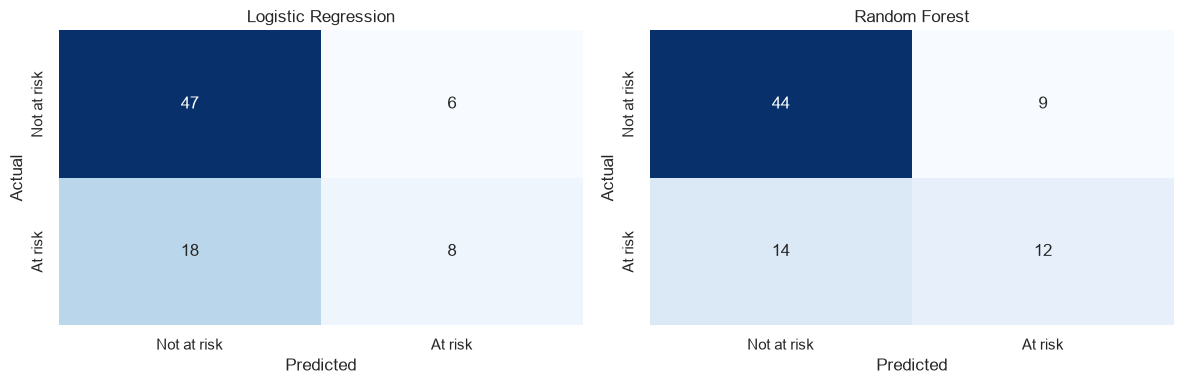

Selected model: Random Forest


In [5]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

results = []
confusion_matrices = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    confusion_matrices[model_name] = confusion_matrix(y_test, predictions)
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "precision_at_risk": precision_score(y_test, predictions, zero_division=0),
            "recall_at_risk": recall_score(y_test, predictions, zero_division=0),
            "f1_at_risk": f1_score(y_test, predictions, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probabilities),
        }
    )

    print(f"\n{model_name} classification report")
    print(classification_report(y_test, predictions, target_names=["Not at risk", "At risk"], zero_division=0))

cv_scores = {}
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={"f1": "f1", "recall": "recall", "roc_auc": "roc_auc"},
    )
    cv_scores[model_name] = {
        metric: scores[f"test_{metric}"].mean() for metric in ("f1", "recall", "roc_auc")
    }

results_df = pd.DataFrame(results).sort_values(
    ["f1_at_risk", "recall_at_risk", "roc_auc"], ascending=False
).reset_index(drop=True)
display(results_df)
display(pd.DataFrame(cv_scores).T.rename(columns={"f1": "cv_f1", "recall": "cv_recall", "roc_auc": "cv_roc_auc"}))

fig, axes = plt.subplots(1, len(models), figsize=(12, 4))
for axis, (model_name, matrix) in zip(np.atleast_1d(axes), confusion_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["Not at risk", "At risk"],
        yticklabels=["Not at risk", "At risk"],
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

selected_model_name = results_df.loc[0, "model"]
final_pipeline = models[selected_model_name]
print(f"Selected model: {selected_model_name}")


In [7]:
import joblib

final_pipeline.fit(X, y)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, MODEL_PATH)

reloaded_pipeline = joblib.load(MODEL_PATH)
synthetic_samples = pd.DataFrame(
    [
        {column: X[column].mode().iloc[0] for column in X.columns},
        {column: X[column].mode().iloc[0] for column in X.columns},
        {column: X[column].mode().iloc[0] for column in X.columns},
    ],
    columns=X.columns,
)
synthetic_samples.loc[0, ["age", "studytime", "failures", "absences"]] = [15, 4, 0, 2]
synthetic_samples.loc[1, ["age", "studytime", "failures", "absences"]] = [18, 1, 1, 18]
synthetic_samples.loc[2, ["age", "studytime", "failures", "absences"]] = [17, 2, 3, 30]

in_memory_predictions = final_pipeline.predict(synthetic_samples)
reloaded_predictions = reloaded_pipeline.predict(synthetic_samples)

prediction_summary = synthetic_samples[["age", "studytime", "failures", "absences"]].copy()
prediction_summary["predicted_at_risk"] = reloaded_predictions
prediction_summary["predicted_label"] = np.where(
    reloaded_predictions == 1, "At risk", "Not at risk"
)

display(prediction_summary)
print(f"Saved pipeline: {MODEL_PATH}")
print(f"Predictions match after reload: {np.array_equal(in_memory_predictions, reloaded_predictions)}")

assert set(LEAKAGE_COLUMNS).isdisjoint(synthetic_samples.columns)
assert np.array_equal(in_memory_predictions, reloaded_predictions)
assert MODEL_PATH.exists()


,age,studytime,failures,absences,predicted_at_risk,predicted_label
0,15,4,0,2,0,Not at risk
1,18,1,1,18,1,At risk
2,17,2,3,30,1,At risk


Saved pipeline: f:\AI_DS_ML\ML01-intern\models\student_risk_pipeline.joblib
Predictions match after reload: True
